<a href="https://colab.research.google.com/github/tharunyalam1702/refinery-performance-predictive-analytics/blob/main/EDA%26%20Programming%20code%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_excel("refinery_eda_dataset.xlsx")

df.columns = df.columns.str.replace('_', ' ')

df.shape
df.head()
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 44 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Date                          300 non-null    datetime64[ns]
 1   Year                          300 non-null    int64         
 2   Month                         300 non-null    int64         
 3   Quarter                       300 non-null    int64         
 4   Brent Price USD per bbl       300 non-null    float64       
 5   WTI Price USD per bbl         300 non-null    float64       
 6   USD INR Exchange Rate         300 non-null    float64       
 7   Crude Import MMT              300 non-null    float64       
 8   Procurement Cost Cr           300 non-null    float64       
 9   Refinery Throughput MMT       300 non-null    float64       
 10  Capacity Utilization Percent  300 non-null    float64       
 11  Yield Efficiency Percent      30

,0
Date,0
Year,0
Month,0
Quarter,0
Brent Price USD per bbl,0
WTI Price USD per bbl,0
USD INR Exchange Rate,0
Crude Import MMT,0
Procurement Cost Cr,0
Refinery Throughput MMT,0


In [ ]:
import pandas as pd

df = pd.read_excel('/content/refinery_eda_dataset.xlsx')
df.columns = df.columns.str.replace('_', ' ')
print(df.columns.tolist())
print(df.head(10))

FileNotFoundError: [Errno 2] No such file or directory: '/content/refinery_eda_dataset.xlsx'

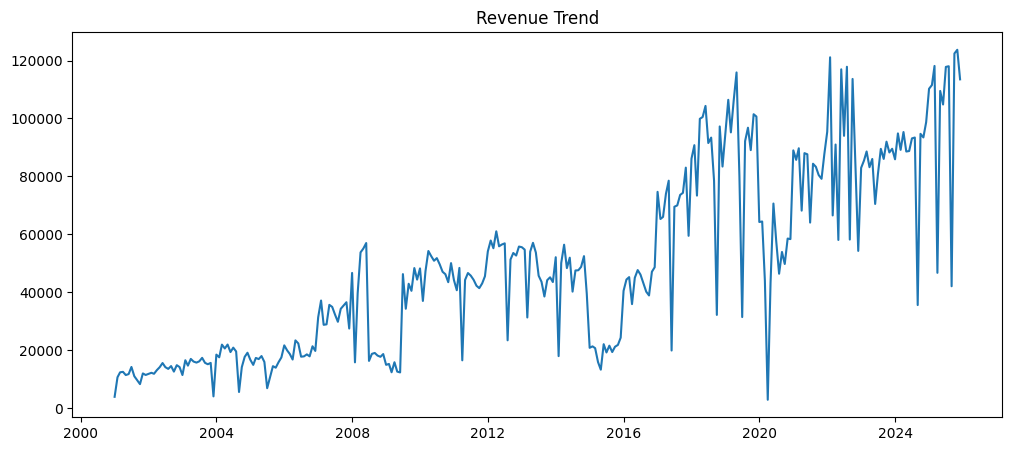

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df['Date'],df['Revenue Cr'])
plt.title("Revenue Trend")
plt.show()

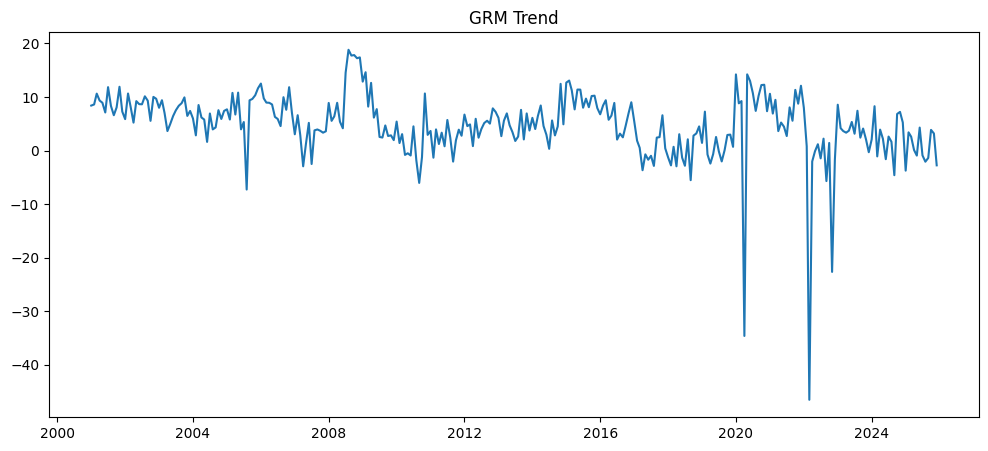

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(df['Date'],df['GRM USD per bbl'])
plt.title("GRM Trend")
plt.show()

<Axes: >

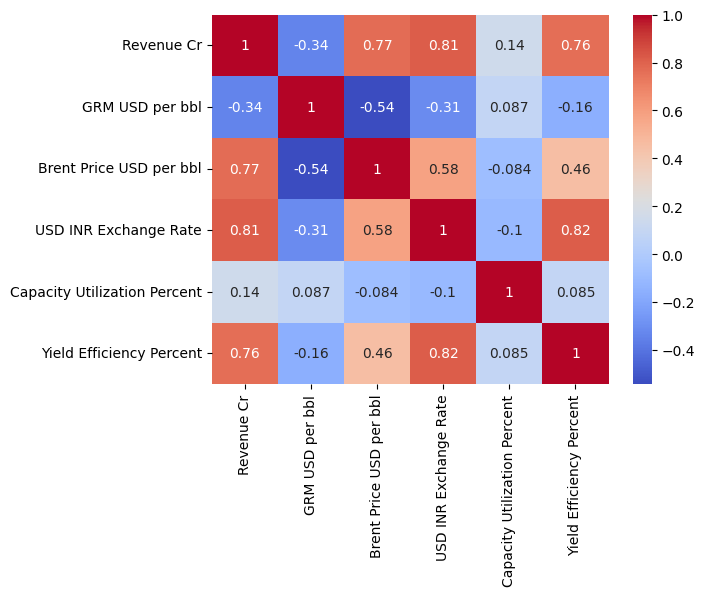

In [ ]:
import seaborn as sns
corr_cols = [
'Revenue Cr',
'GRM USD per bbl',
'Brent Price USD per bbl',
'USD INR Exchange Rate',
'Capacity Utilization Percent',
'Yield Efficiency Percent'
]

sns.heatmap(
df[corr_cols].corr(),
annot=True,
cmap='coolwarm'
)

<Axes: >

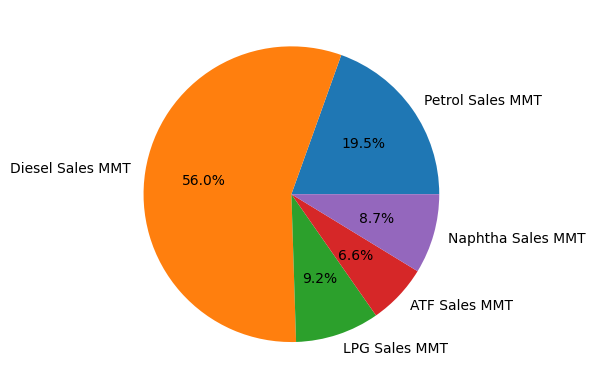

In [ ]:
sales_cols = [
'Petrol Sales MMT',
'Diesel Sales MMT',
'LPG Sales MMT',
'ATF Sales MMT',
'Naphtha Sales MMT'
]

df[sales_cols].sum().plot(
kind='pie',
autopct='%1.1f%%'
)

<Axes: xlabel='Capacity Utilization Percent', ylabel='Revenue Cr'>

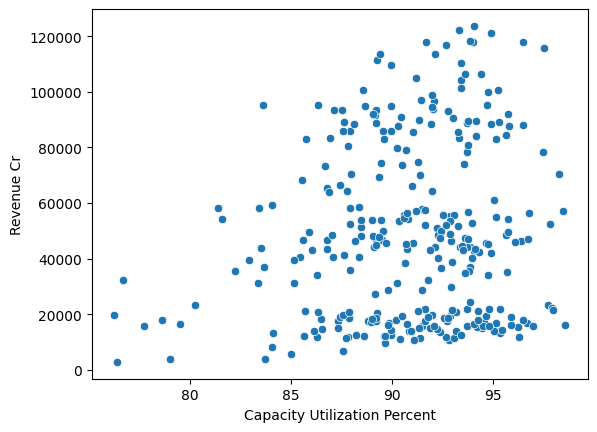

In [ ]:
sns.scatterplot(
x='Capacity Utilization Percent',
y='Revenue Cr',
data=df
)

Text(0.5, 1.0, 'Revenue Growth %')

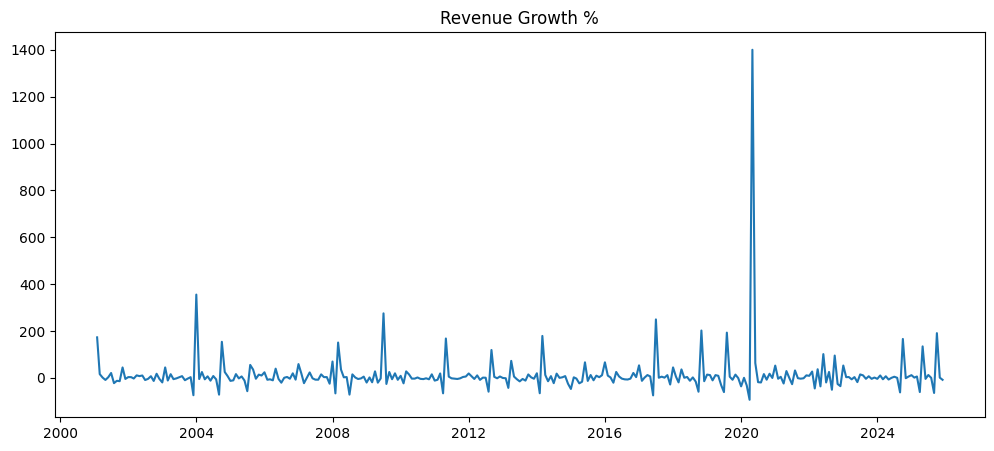

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(
df['Date'],
df['Revenue Growth Percent']
)
plt.title("Revenue Growth %")

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


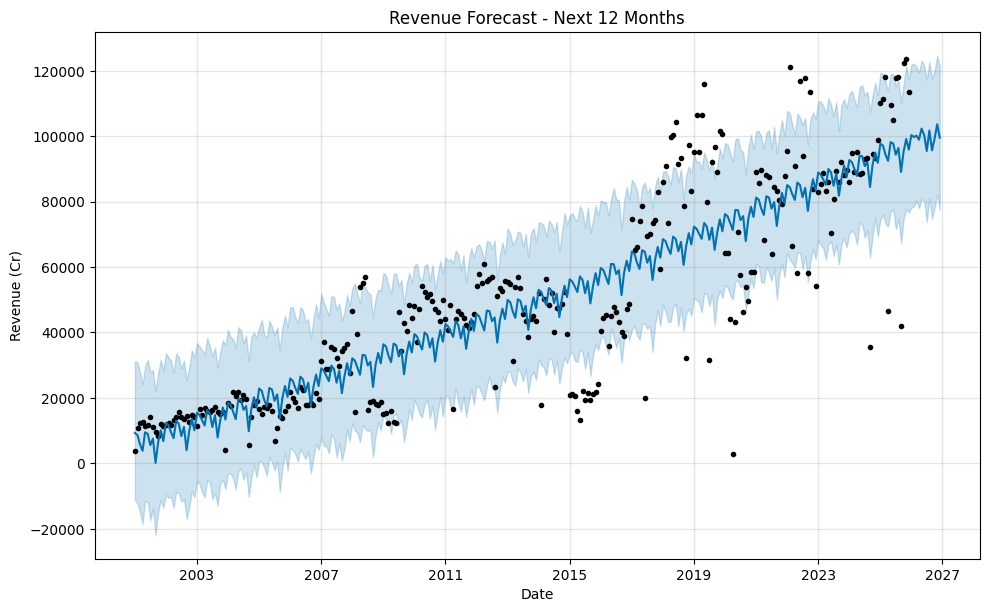

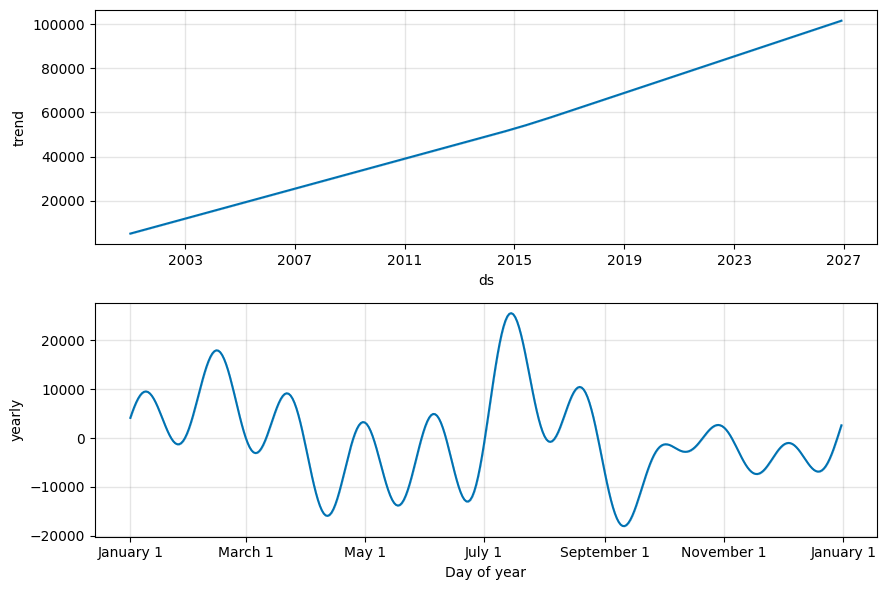

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# REVENUE FORECASTING USING PROPHET
# PROJECT: Refinery Intelligence Hub
# OBJECTIVE:
# Predict future refinery revenue using 25 years of historical data.
#
# INPUT:
# Date column + Revenue_Cr column
#
# OUTPUT:
# Future Revenue Forecast (Next 12 Months)
# Forecast Chart
# Forecast CSV File
# ============================================================


# ------------------------------------------------------------
# STEP 1: Install Prophet
# Prophet is a time-series forecasting library developed by Meta.
# It automatically learns:
# - Trend
# - Seasonality
# - Growth patterns
# ------------------------------------------------------------

!pip install prophet


# ------------------------------------------------------------
# STEP 2: Import Required Libraries
# pandas -> data handling
# matplotlib -> plotting charts
# Prophet -> forecasting model
# ------------------------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt

from prophet import Prophet


# ------------------------------------------------------------
# STEP 3: Load Dataset
#
# INPUT:
# refinery_eda_dataset.xlsx
#
# OUTPUT:
# DataFrame containing refinery data
# ------------------------------------------------------------

df = pd.read_excel('/content/refinery_eda_dataset.xlsx') # Re-added data loading
df.columns = df.columns.str.replace('_', ' ') # Re-added column renaming


# ------------------------------------------------------------
# STEP 4: Select Required Columns
#
# Prophet only accepts:
#
# ds = Date column
# y  = Target variable to forecast
#
# Here:
# ds = Date
# y  = Revenue_Cr
# ------------------------------------------------------------

forecast_df = df[['Date', 'Revenue Cr']]


# ------------------------------------------------------------
# STEP 5: Rename Columns
#
# Prophet requires exact names:
#
# ds -> date column
# y  -> target column
# ------------------------------------------------------------

forecast_df.columns = ['ds', 'y']


# View first few rows
forecast_df.head()


# ------------------------------------------------------------
# STEP 6: Create Prophet Model
#
# Creates an empty forecasting model.
#
# Model will learn:
# - Revenue trend
# - Monthly patterns
# - Long-term growth
# ------------------------------------------------------------

model = Prophet()


# ------------------------------------------------------------
# STEP 7: Train Model
#
# INPUT:
# Historical Revenue Data (2001-2025)
#
# PROCESS:
# Learns historical patterns
#
# OUTPUT:
# Trained forecasting model
# ------------------------------------------------------------

model.fit(forecast_df)


# ------------------------------------------------------------
# STEP 8: Create Future Dates
#
# periods = 12
#
# Meaning:
# Forecast next 12 months
#
# freq='M'
# Means monthly forecasting
# ------------------------------------------------------------

future = model.make_future_dataframe(
    periods=12,
    freq='M'
)


# Check future dates
future.tail()


# ------------------------------------------------------------
# STEP 9: Generate Forecast
#
# INPUT:
# Future dates
#
# OUTPUT:
# Predicted Revenue
#
# yhat       = predicted revenue
# yhat_lower = lower estimate
# yhat_upper = upper estimate
# ------------------------------------------------------------

forecast = model.predict(future)


# ------------------------------------------------------------
# STEP 10: View Forecast Values
#
# Shows next 12 month predictions
# ------------------------------------------------------------

forecast[['ds',
          'yhat',
          'yhat_lower',
          'yhat_upper']].tail(12)


# ------------------------------------------------------------
# STEP 11: Plot Revenue Forecast
#
# BLUE LINE:
# Historical Revenue
#
# FUTURE SECTION:
# Predicted Revenue
#
# SHADED AREA:
# Prediction uncertainty range
# ------------------------------------------------------------

fig = model.plot(forecast)

plt.title("Revenue Forecast - Next 12 Months")
plt.xlabel("Date")
plt.ylabel("Revenue (Cr)")
plt.show()


# ------------------------------------------------------------
# STEP 12: Plot Components
#
# Shows:
#
# TREND:
# Overall revenue growth
#
# YEARLY:
# Seasonal yearly pattern
#
# This chart helps explain
# why the model predicts future values.
# ------------------------------------------------------------

fig2 = model.plot_components(forecast)

plt.show()


# ------------------------------------------------------------
# STEP 13: Export Forecast Results
#
# Creates a CSV file
#
# Useful for:
# - Power BI
# - Dashboard
# - Presentation
# ------------------------------------------------------------

forecast_output = forecast[['ds', 'yhat']]

forecast_output.to_csv(
    'Revenue_Forecast.csv',
    index=False
)


# ------------------------------------------------------------
# STEP 14: Download Forecast File
#
# OUTPUT:
# Revenue_Forecast.csv
#
# Import this file into Power BI
# ------------------------------------------------------------

from google.colab import files

files.download('Revenue_Forecast.csv')


# ============================================================
# BUSINESS INTERPRETATION
# ============================================================
#
# EDA Answered:
# "What happened?"
#
# Forecasting Answers:
# "What is likely to happen next?"
#
# Business Use:
#
# - Revenue Planning
# - Budgeting
# - Procurement Planning
# - Production Planning
# - Strategic Forecasting
#
# Example:
#
# If model predicts:
#
# Jan 2026 = 125000 Cr
# Feb 2026 = 128000 Cr
# Mar 2026 = 130000 Cr
#
# Management can prepare:
#
# - Crude procurement
# - Inventory levels
# - Production schedules
# - Revenue targets
#
# ============================================================

In [ ]:
from google.colab import files

files.download('Revenue_Forecast.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


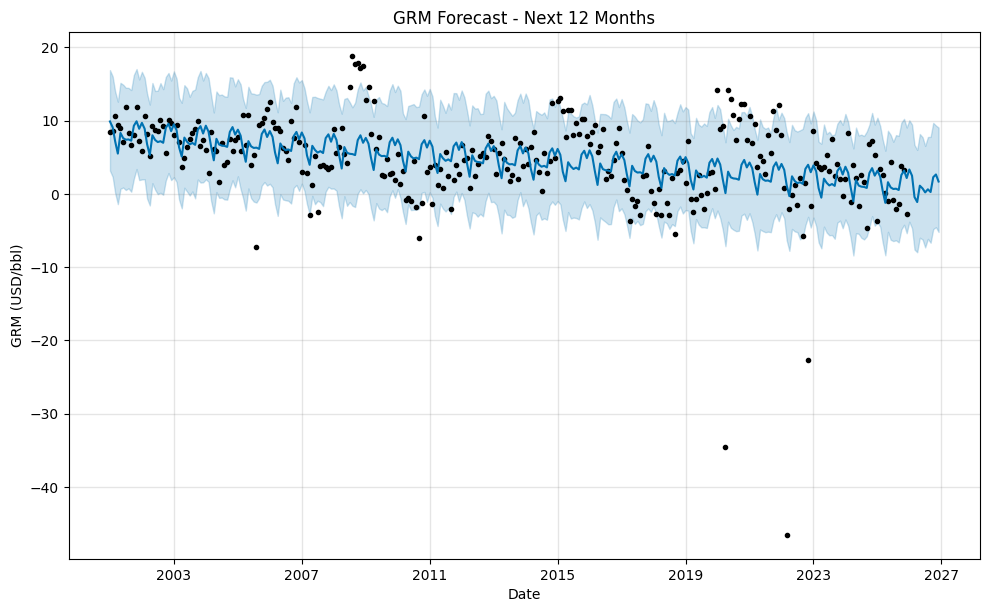

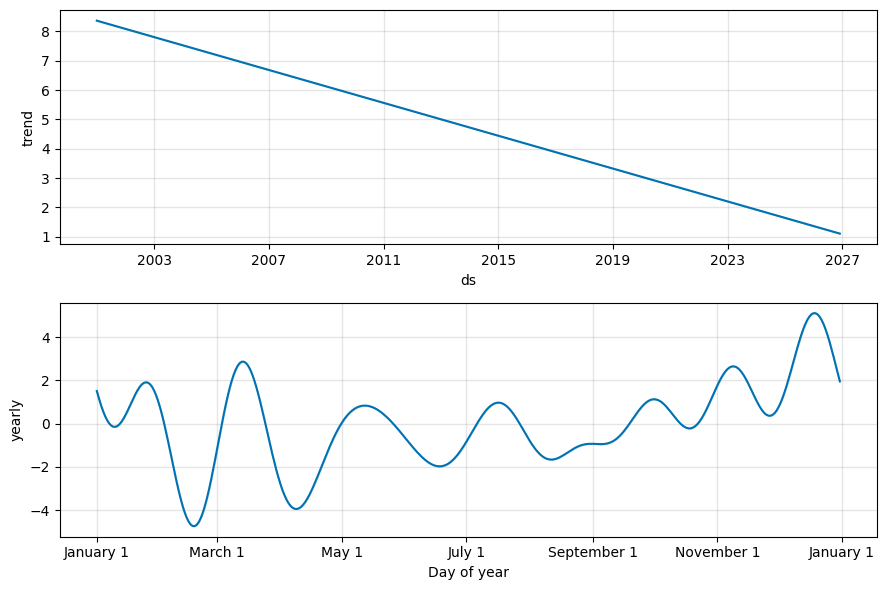

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# GRM FORECASTING USING PROPHET
# PROJECT: Refinery Intelligence Hub
#
# OBJECTIVE:
# Predict future Gross Refining Margin (GRM) for the next 12 months.
#
# INPUT:
# Date column + GRM_USD_per_bbl column
#
# OUTPUT:
# Future GRM Forecast
# Forecast Chart
# Forecast CSV File
#
# BUSINESS VALUE:
# Helps management estimate future profitability and
# understand margin risks before they occur.
# ============================================================


# ------------------------------------------------------------
# STEP 1: Import Libraries
# ------------------------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet


# ------------------------------------------------------------
# STEP 2: Load Dataset
# ------------------------------------------------------------

df = pd.read_excel('/content/refinery_eda_dataset.xlsx') # Re-added data loading
df.columns = df.columns.str.replace('_', ' ') # Re-added column renaming


# ------------------------------------------------------------
# STEP 3: Select Date and GRM Columns
#
# ds = Date
# y  = Target variable (GRM)
# ------------------------------------------------------------

grm_df = df[['Date', 'GRM USD per bbl']]


# ------------------------------------------------------------
# STEP 4: Rename Columns
#
# Prophet requires:
# ds = date column
# y  = target column
# ------------------------------------------------------------

grm_df.columns = ['ds', 'y']

grm_df.head()


# ------------------------------------------------------------
# STEP 5: Create Prophet Model
#
# Prophet learns:
# - Trend
# - Seasonality
# - Historical patterns
# ------------------------------------------------------------

model = Prophet()


# ------------------------------------------------------------
# STEP 6: Train Model
#
# INPUT:
# 25 years of GRM history
#
# OUTPUT:
# Trained forecasting model
# ------------------------------------------------------------

model.fit(grm_df)


# ------------------------------------------------------------
# STEP 7: Create Future Dates
#
# periods=12
# Means forecast next 12 months
# ------------------------------------------------------------

future = model.make_future_dataframe(
    periods=12,
    freq='M'
)

future.tail()


# ------------------------------------------------------------
# STEP 8: Generate Forecast
#
# yhat       = predicted GRM
# yhat_lower = lower estimate
# yhat_upper = upper estimate
# ------------------------------------------------------------

forecast = model.predict(future)


# ------------------------------------------------------------
# STEP 9: View Next 12 Month Forecast
# ------------------------------------------------------------

forecast[['ds',
          'yhat',
          'yhat_lower',
          'yhat_upper']].tail(12)


# ------------------------------------------------------------
# STEP 10: Plot GRM Forecast
#
# Shows:
# Historical GRM
# +
# Future Predicted GRM
# ------------------------------------------------------------

fig = model.plot(forecast)

plt.title("GRM Forecast - Next 12 Months")
plt.xlabel("Date")
plt.ylabel("GRM (USD/bbl)")
plt.show()


# ------------------------------------------------------------
# STEP 11: Plot Forecast Components
#
# Shows:
# Trend
# Yearly Seasonality
#
# Helps explain why model predicts future values.
# ------------------------------------------------------------

fig2 = model.plot_components(forecast)

plt.show()


# ------------------------------------------------------------
# STEP 12: Export Forecast Results
#
# Creates CSV for Power BI
# ------------------------------------------------------------

grm_forecast = forecast[['ds', 'yhat']]

grm_forecast.to_csv(
    'GRM_Forecast.csv',
    index=False
)


# ------------------------------------------------------------
# STEP 13: Download Forecast File
# ------------------------------------------------------------

from google.colab import files

files.download('GRM_Forecast.csv')


# ============================================================
# BUSINESS INTERPRETATION
# ============================================================
#
# EDA Answered:
# "What happened to profitability?"
#
# Forecasting Answers:
# "What is likely to happen to profitability next year?"
#
# Example:
#
# Jan 2026 = 7.2 USD/bbl
# Feb 2026 = 7.5 USD/bbl
# Mar 2026 = 7.8 USD/bbl
#
# Management can use this forecast for:
#
# - Financial Planning
# - Budgeting
# - Procurement Strategy
# - Margin Risk Management
# - Business Decision Making
#
# ============================================================

In [ ]:
# ============================================================
# RANDOM FOREST REVENUE PREDICTION MODEL
#
# OBJECTIVE:
# Predict Revenue using business variables.
#
# INPUTS:
# Brent Price
# USD/INR Exchange Rate
# Capacity Utilization
# Yield Efficiency
#
# OUTPUT:
# Revenue Prediction
#
# BUSINESS VALUE:
# Enables What-If Scenario Analysis
# ============================================================


# ------------------------------------------------------------
# STEP 1: Import Libraries
# ------------------------------------------------------------

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# ------------------------------------------------------------
# STEP 2: Load Dataset
# ------------------------------------------------------------

df = pd.read_excel('/content/refinery_eda_dataset.xlsx') # Re-added data loading
df.columns = df.columns.str.replace('_', ' ') # Re-added column renaming


# ------------------------------------------------------------
# STEP 3: Select Features (Inputs)
#
# X = Independent Variables
# ------------------------------------------------------------

X = df[[
    'Brent Price USD per bbl',
    'USD INR Exchange Rate',
    'Capacity Utilization Percent',
    'Yield Efficiency Percent'
]]


# ------------------------------------------------------------
# STEP 4: Select Target
#
# y = Revenue
# ------------------------------------------------------------

y = df['Revenue Cr']


# ------------------------------------------------------------
# STEP 5: Split Dataset
#
# 80% Training
# 20% Testing
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# ------------------------------------------------------------
# STEP 6: Create Random Forest Model
# ------------------------------------------------------------

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)


# ------------------------------------------------------------
# STEP 7: Train Model
# ------------------------------------------------------------

rf_model.fit(
    X_train,
    y_train
)


# ------------------------------------------------------------
# STEP 8: Make Predictions
# ------------------------------------------------------------

y_pred = rf_model.predict(X_test)


# ------------------------------------------------------------
# STEP 9: Evaluate Model
# ------------------------------------------------------------

mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)


# ------------------------------------------------------------
# STEP 10: Feature Importance
#
# Shows which factor impacts Revenue most
# ------------------------------------------------------------

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

MAE : 4868.711066666667
RMSE: 8567.608562789193
R²  : 0.925544424425451
                        Feature  Importance
1         USD INR Exchange Rate    0.676183
0       Brent Price USD per bbl    0.197464
2  Capacity Utilization Percent    0.087198
3      Yield Efficiency Percent    0.039155


In [ ]:
# ============================================================
# SCENARIO ANALYSIS USING RANDOM FOREST
#
# OBJECTIVE:
# Check how Revenue changes when Brent Crude Price changes.
#
# INPUT:
# Brent Price
# USD/INR
# Capacity Utilization
# Yield Efficiency
#
# OUTPUT:
# Predicted Revenue under different business scenarios
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Create Different Business Scenarios
#
# We keep:
# USD/INR = 83
# Capacity = 92%
# Yield = 95%
#
# Only Brent Price changes
# ------------------------------------------------------------

scenarios = pd.DataFrame({

    'Brent Price USD per bbl':[70,80,90,100,110],

    'USD INR Exchange Rate':[83,83,83,83,83],

    'Capacity Utilization Percent':[92,92,92,92,92],

    'Yield Efficiency Percent':[95,95,95,95,95]

})

# ------------------------------------------------------------
# Predict Revenue using trained Random Forest model
# ------------------------------------------------------------

scenarios['Predicted_Revenue'] = rf_model.predict(scenarios)

# ------------------------------------------------------------
# Display Scenario Results
# ------------------------------------------------------------

print(scenarios)

# ------------------------------------------------------------
# Plot Scenario Analysis Chart
# ------------------------------------------------------------

plt.figure(figsize=(8,5))

plt.plot(
    scenarios['Brent Price USD per bbl'],
    scenarios['Predicted_Revenue'],
    marker='o'
)

plt.title('Impact of Brent Price on Revenue')

plt.xlabel('Brent Price (USD/bbl)')

plt.ylabel('Predicted Revenue (Cr)')

plt.grid(True)

plt.show()

# ------------------------------------------------------------
# Export for Power BI
# ------------------------------------------------------------

scenarios.to_csv(
    'Scenario_Analysis.csv',
    index=False
)

# ------------------------------------------------------------
# Download File
# ------------------------------------------------------------

from google.colab import files

files.download('Scenario_Analysis.csv')

# ============================================================
# BUSINESS INTERPRETATION
#
# Brent = 70  → Revenue = ?
# Brent = 80  → Revenue = ?
# Brent = 90  → Revenue = ?
# Brent = 100 → Revenue = ?
# Brent = 110 → Revenue = ?
#
# Helps management understand:
# "What happens to Revenue if crude prices change?"
# ============================================================



NameError: name 'rf_model' is not defined